# 01. Generative AI vs Discriminative Models

## Theory

Artificial Intelligence and Machine Learning use different types of models to learn from data and perform various tasks. Two important types of models are **Generative Models** and **Discriminative Models**. Although both learn from data, their purpose and working methods are different.

## Generative Models

Generative models learn the underlying patterns and distribution of the given data. After learning these patterns, they can generate new data that is similar to the original training data.

Generative models are commonly used for generating text, images, audio, and other types of content. Examples of generative models include **Generative Adversarial Networks (GANs), Variational Autoencoders (VAEs), and Large Language Models (LLMs)**.

## Discriminative Models

Discriminative models are mainly used to classify data or make predictions. They learn the relationship between input data and its corresponding output or class. These models identify the differences between classes and use this information to make predictions for new data.

Discriminative models are commonly used in tasks such as spam detection, image classification, and sentiment analysis. Examples include **Logistic Regression, Support Vector Machines (SVM), Decision Trees, and classification-based Neural Networks**.

## Comparison

| Generative Models | Discriminative Models |
|---|---|
| Learn the distribution and patterns of data. | Learn the relationship between input and output. |
| Can generate new data. | Mainly classify or predict data. |
| Used for content generation. | Used for classification and prediction. |
| Examples: GAN, VAE, LLM. | Examples: SVM, Logistic Regression, Decision Tree. |

The main difference between the two is that **Generative Models focus on creating new data, whereas Discriminative Models focus on distinguishing between different classes and making predictions**.

## Conclusion

From this practical, I understood the basic concepts and differences between Generative AI and Discriminative Models. Generative Models are useful for creating new data based on learned patterns, while Discriminative Models are mainly used for classification and prediction tasks. Both types of models have important applications in Artificial Intelligence and Machine Learning, and the suitable model can be selected according to the requirements of the task.


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28)
Testing images : (10000, 28, 28)

Training Discriminative Model...


/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8974 - loss: 0.3751 - val_accuracy: 0.9575 - val_loss: 0.1664
Epoch 2/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9507 - loss: 0.1735 - val_accuracy: 0.9633 - val_loss: 0.1257
Epoch 3/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9643 - loss: 0.1255 - val_accuracy: 0.9693 - val_loss: 0.1098

Discriminative Model Accuracy: 0.9639000296592712

Training Generative Model...
Epoch 1/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0469 - val_loss: 0.0244
Epoch 2/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0201 - val_loss: 0.0171
Epoch 3/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0158 - val_loss: 0.0145
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


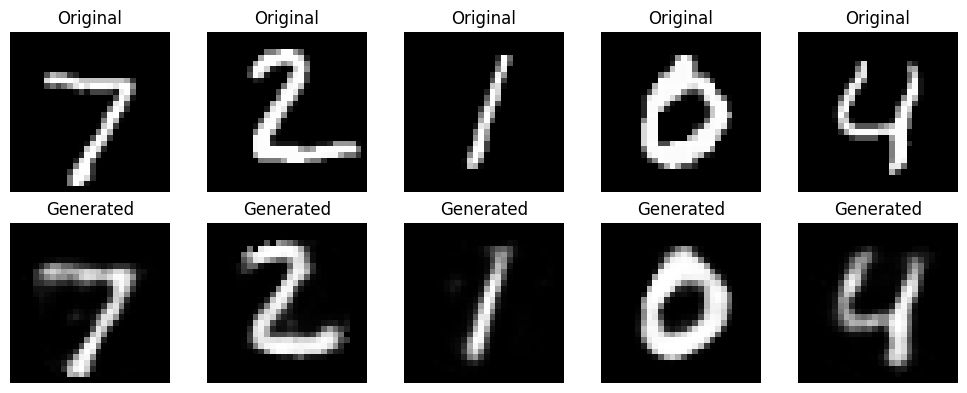

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Reshape

# --------------------------------------------------
# 1. Load MNIST Dataset
# --------------------------------------------------

(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize pixel values: 0-255 -> 0-1
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Training images:", x_train.shape)
print("Testing images :", x_test.shape)


# --------------------------------------------------
# 2. Discriminative Model - Classification
# --------------------------------------------------

classifier = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation="relu"),
    Dense(10, activation="softmax")
])

classifier.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("\nTraining Discriminative Model...")

classifier.fit(
    x_train,
    y_train,
    epochs=3,
    batch_size=128,
    validation_split=0.1
)

loss, accuracy = classifier.evaluate(x_test, y_test, verbose=0)

print("\nDiscriminative Model Accuracy:", accuracy)


# --------------------------------------------------
# 3. Generative Model - Autoencoder
# --------------------------------------------------

autoencoder = Sequential([
    Flatten(input_shape=(28, 28)),

    # Encoder
    Dense(128, activation="relu"),
    Dense(32, activation="relu"),

    # Decoder
    Dense(128, activation="relu"),
    Dense(784, activation="sigmoid"),

    Reshape((28, 28))
])

autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

print("\nTraining Generative Model...")

autoencoder.fit(
    x_train,
    x_train,
    epochs=3,
    batch_size=128,
    validation_split=0.1
)


# --------------------------------------------------
# 4. Image Reconstruction
# --------------------------------------------------

reconstructed = autoencoder.predict(x_test[:5])


# --------------------------------------------------
# 5. Display Original and Reconstructed Images
# --------------------------------------------------

plt.figure(figsize=(10, 4))

for i in range(5):

    # Original Image
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i], cmap="gray")
    plt.axis("off")
    plt.title("Original")

    # Reconstructed Image
    plt.subplot(2, 5, i + 6)
    plt.imshow(reconstructed[i], cmap="gray")
    plt.axis("off")
    plt.title("Generated")

plt.tight_layout()
plt.show()